In [2]:
# notebooks/01_eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots folder if not exists
os.makedirs("plots", exist_ok=True)

# Load dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Basic info
print("Shape of dataset:", df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types
print("\nData Types:\n")
print(df.dtypes)

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Data Types:

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilli

In [6]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check missing again
print(df['TotalCharges'].isnull().sum())

11


Churn
No     5174
Yes    1869
Name: count, dtype: int64


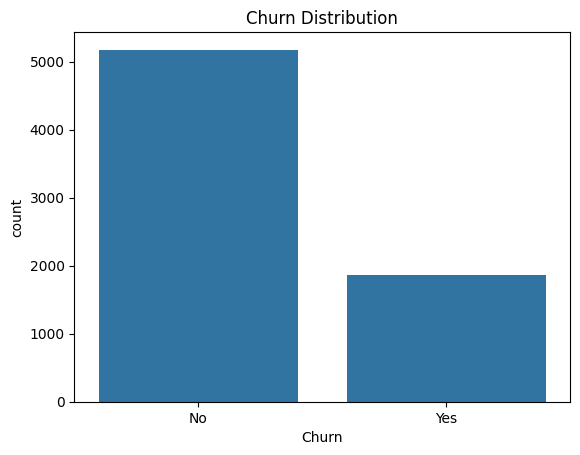

In [7]:
# Churn distribution
churn_counts = df['Churn'].value_counts()

print(churn_counts)

# Plot
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.savefig("plots/churn_distribution.png")
plt.show()


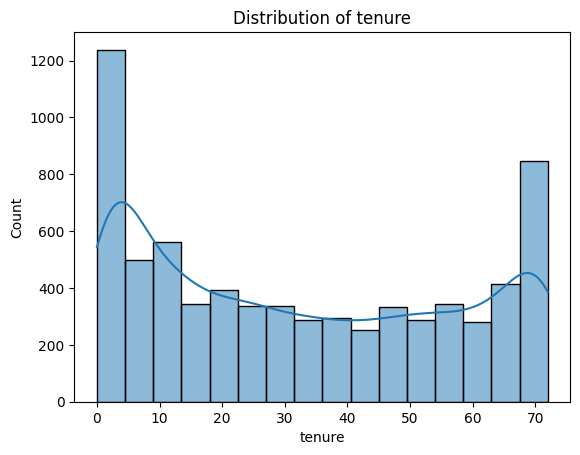

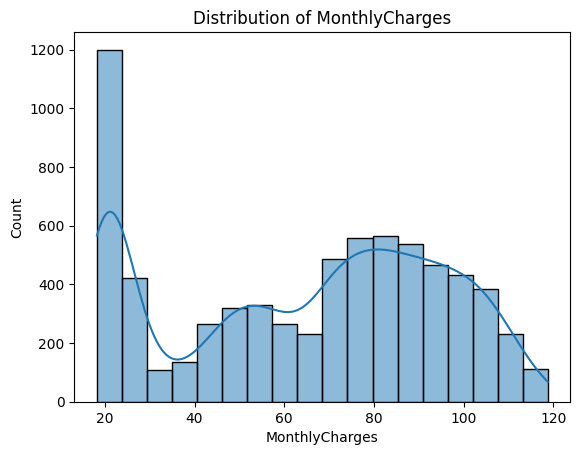

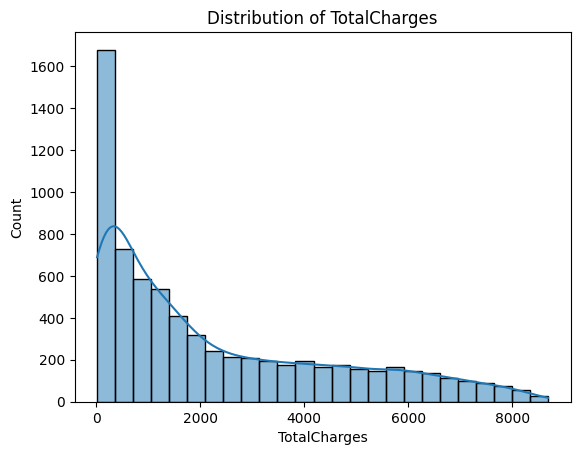

In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.savefig(f"plots/{col}_distribution.png")
    plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5704\3642142826.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


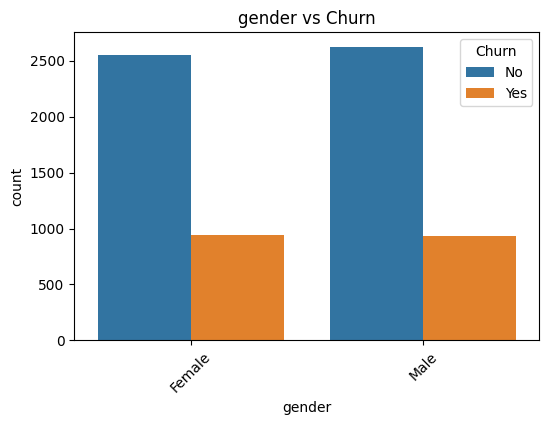

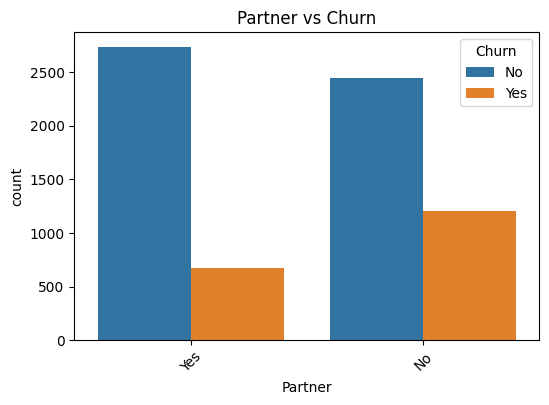

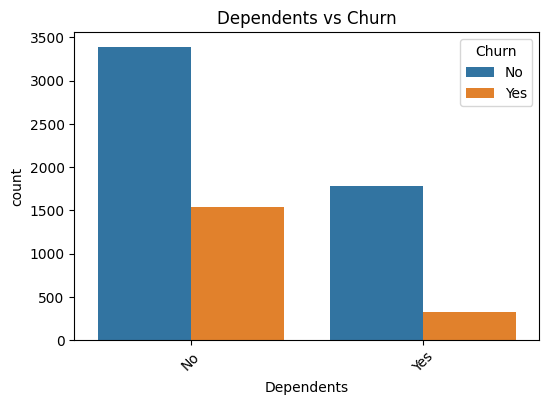

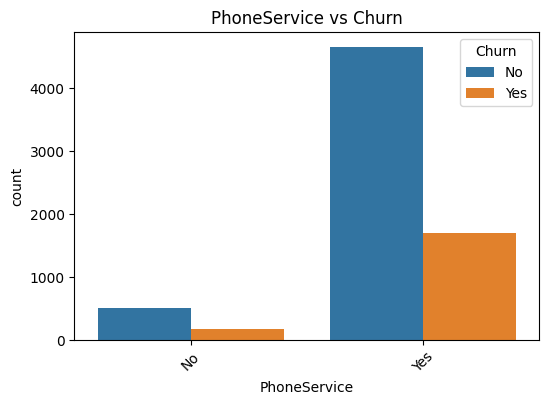

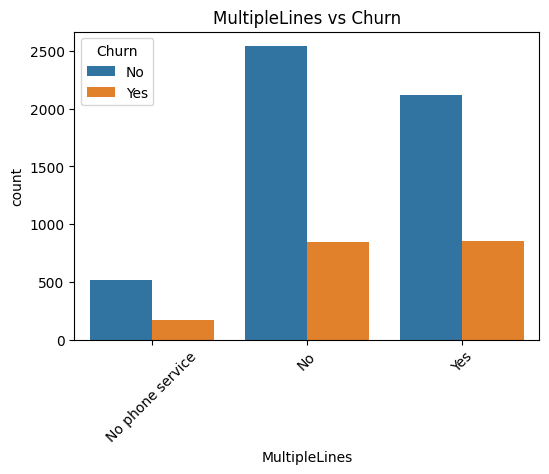

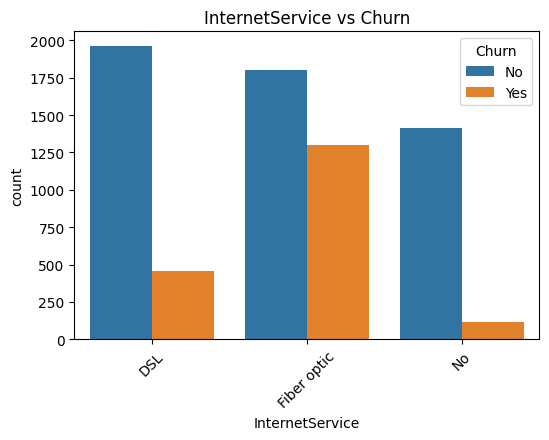

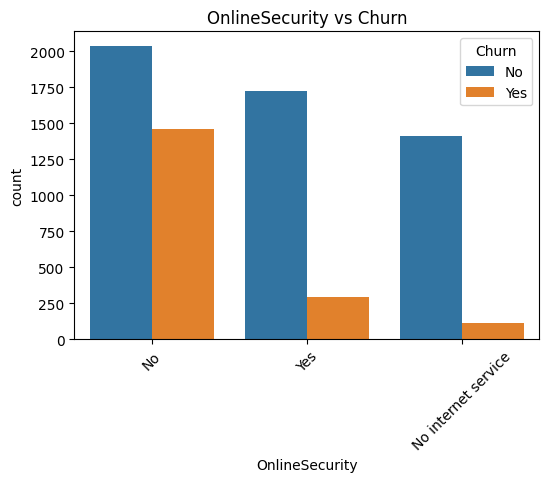

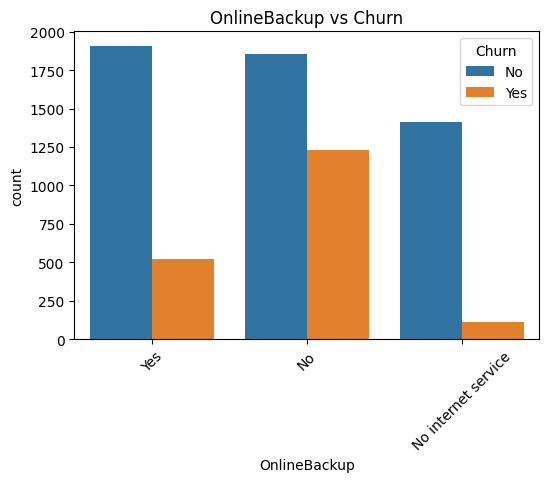

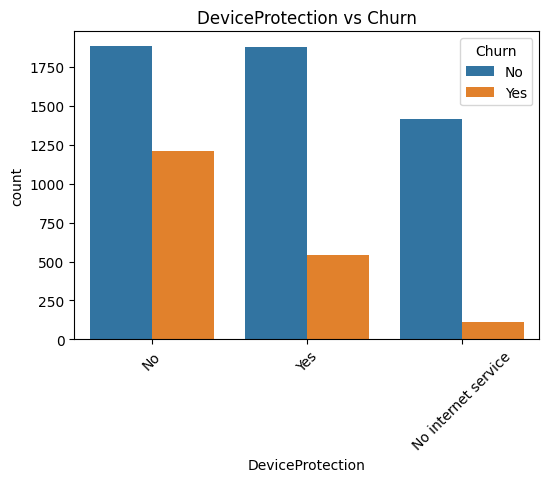

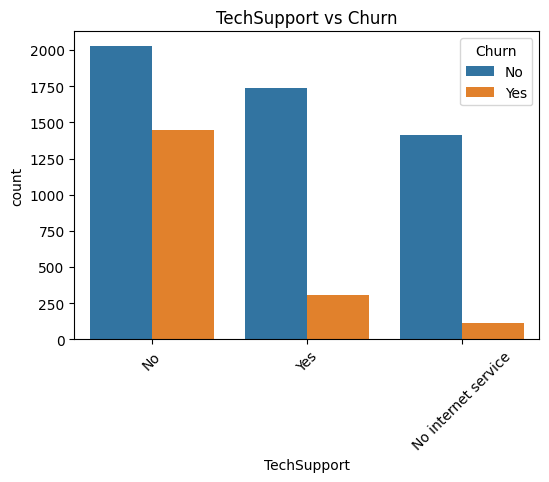

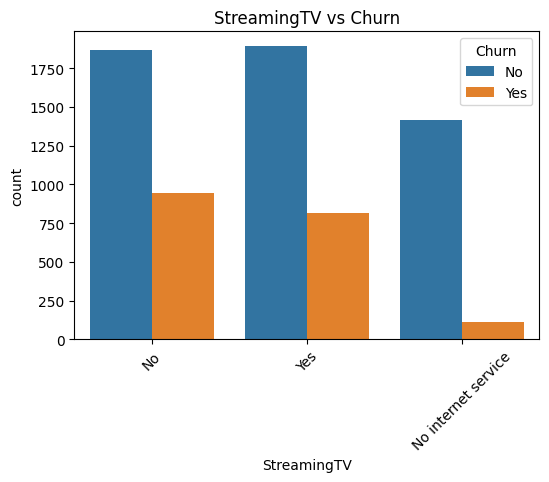

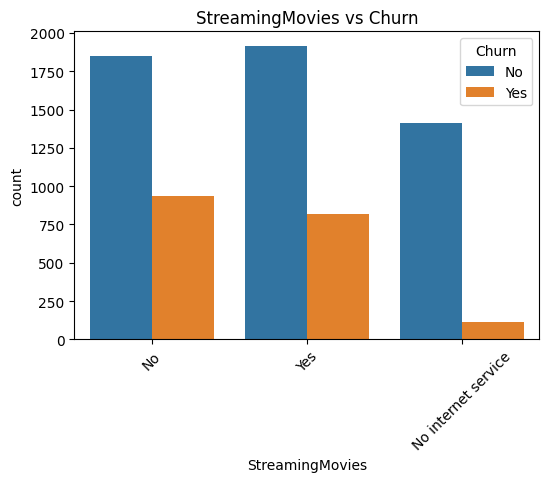

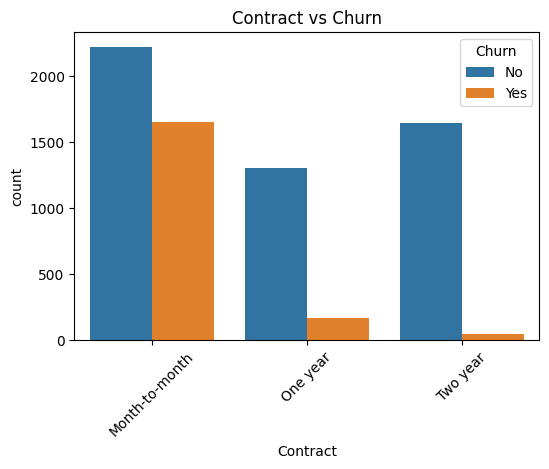

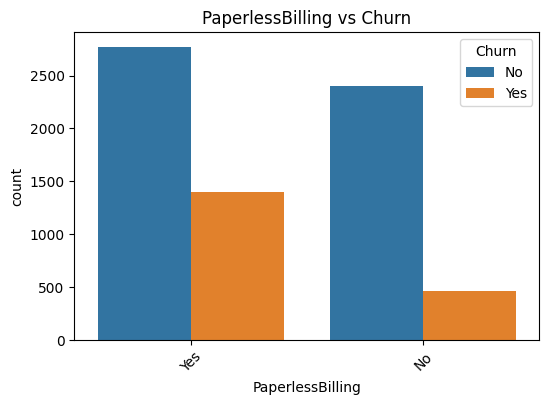

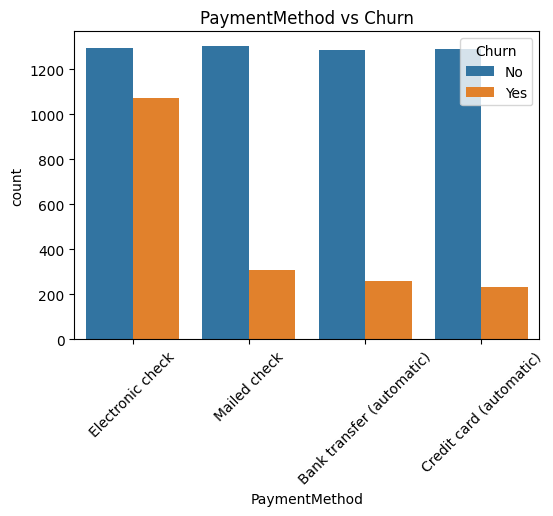

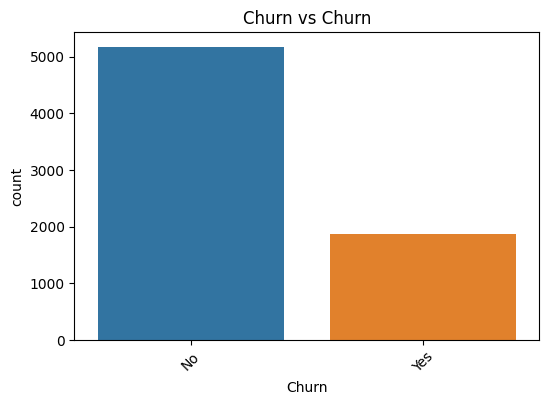

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != 'customerID':
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Churn', data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Churn")
        plt.savefig(f"plots/{col}_vs_churn.png")
        plt.show()

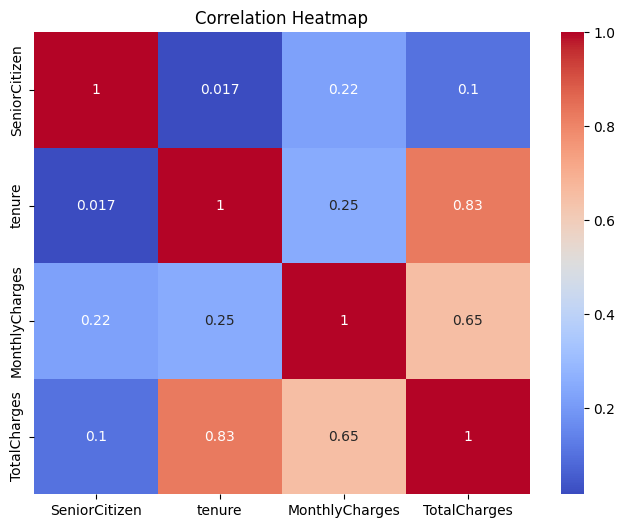

In [10]:
# Only numeric
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("plots/correlation_heatmap.png")
plt.show()

In [23]:
churn_percent = df['Churn'].value_counts(normalize=True) * 100
print(churn_percent)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [26]:
df.drop(columns=['customerID'], errors='ignore', inplace=True)

Key Insights:

1. Dataset has ~7043 rows and 21 columns
2. TotalCharges had hidden missing values
3. Churn is imbalanced (~70% No, ~30% Yes)
4. Customers with month-to-month contracts churn more
5. Short tenure customers are more likely to churn
6. Fiber optic users show higher churn rate